## Investigate arm concentration of remote theta

In [1]:
# From position info:
# find a) animal speed > 4cm/s
#      b) when animal in outer arm > proportion 0.1

# From decode:
# find posterior in local arm sum less than 50%
# 
# For each bin, get # of arms with >10% posterior
# For each bin, get # of arms with >20% posterior
# For each bin, get # of arms with >30% posterior

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
# ignore datajoint+jupyter async warnings
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)
warnings.simplefilter('ignore', category=ResourceWarning)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import logging
import os
import cupy as cp
from scipy import linalg
import pickle

FORMAT = '%(asctime)s %(message)s'

logging.basicConfig(level='INFO', format=FORMAT, datefmt='%d-%b-%y %H:%M:%S')
from spyglass.decoding.v0.clusterless import ClusterlessClassifierParameters

14-Apr-26 16:00:50 DataJoint is configured from /home/shijiegu/.datajoint_config.json
[2026-04-14 16:00:54,959][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
14-Apr-26 16:00:54 DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [4]:
from spyglass.shijiegu.Analysis_SGU import (EpochPos,TrialChoice,Decode,
    DecodeIngredients,DecodeResultsLinear,MUA,DecodeIngredientsLikelihood,DecodeResultsLinear)
from spyglass.shijiegu.changeOfMind_figures.supp_decode import return_diff_file
from spyglass.linearization.v0.main import IntervalLinearizedPosition
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.shijiegu.decodeHelpers import session2position_name

from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.ripple_add_replay import select_subset_helper_pd, select_subset_helper
from spyglass.shijiegu.changeOfMind_helper import nodes
from spyglass.shijiegu.ripple_add_replay import position_posterior2arm_posterior
from spyglass.shijiegu.changeOfMind_triggered import linear_map
from spyglass.shijiegu.changeOfMind_figures.supp_decode_concentration import return_concentration_animal, return_concentration_day

[16:01:05][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
14-Apr-26 16:01:05 Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:01:05][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
14-Apr-26 16:01:05 Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[16:01:05][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
14-Apr-26 16:01:05 Deprecation: this class has been 

In [17]:
list_of_days_animals = {}
success_animal = {}

animal = 'eliot'
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']


animal = 'molly'
list_of_days_animals[animal] = ['20220416','20220417','20220418','20220419','20220420']

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']

animal = "julio"
list_of_days_animals[animal] = ['20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = "klein"
list_of_days_animals[animal] = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108']

In [ ]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure_supp_decode'

for animal in ["molly","eliot","julio","klein","lewis"]:
    nonlocal_concentration = return_concentration_animal(animal,
                                                            list_of_days_animals[animal])
    data = {"nonlocal_concentration": nonlocal_concentration}

    data_filename = f"time_bin_arm_concentration_{animal}.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {output_path}")

[2026-04-27 11:16:49,711][WARNING]: Skipped checksum for file with hash: 039acaf2-b93a-01f8-b88a-74010c1d5c28, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_RLS96PKWQ9.nwb
27-Apr-26 11:16:49 Skipped checksum for file with hash: 039acaf2-b93a-01f8-b88a-74010c1d5c28, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_RLS96PKWQ9.nwb


Processing molly day: 20220416
Processing molly 20220416 session: 02_Seq2Session1
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 2, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
Processing molly 20220416 session: 04_Seq2Session2
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
Processing molly 20220416 session: 06_Seq2Session3
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 6, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
Processing molly 20220416 session: 08_Seq2Session4


[2026-04-27 11:17:00,334][WARNING]: Skipped checksum for file with hash: 40b07149-ae6f-e91a-3635-368d50f45f16, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_U2PAI7SDPA.nwb
27-Apr-26 11:17:00 Skipped checksum for file with hash: 40b07149-ae6f-e91a-3635-368d50f45f16, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_U2PAI7SDPA.nwb


Processing molly 20220416 session: 10_Seq2Session5
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 10, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
Processing molly day: 20220417
Processing molly 20220417 session: 02_Seq2Session1


[2026-04-27 11:17:10,982][WARNING]: Skipped checksum for file with hash: c0591f47-c3f0-2a9f-0323-0fe93e973198, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_BZK7V72DS4.nwb
27-Apr-26 11:17:10 Skipped checksum for file with hash: c0591f47-c3f0-2a9f-0323-0fe93e973198, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_BZK7V72DS4.nwb


...

Processing lewis 20240107 session: 08_Rev2Session4


[2026-04-27 11:54:37,003][WARNING]: Skipped checksum for file with hash: 93b2a081-e3b0-4f8e-bfab-f0099eaf2279, and path: /stelmo/nwb/analysis/lewis20240107/lewis20240107_Z5RRLL533L.nwb
27-Apr-26 11:54:37 Skipped checksum for file with hash: 93b2a081-e3b0-4f8e-bfab-f0099eaf2279, and path: /stelmo/nwb/analysis/lewis20240107/lewis20240107_Z5RRLL533L.nwb


Processing lewis 20240107 session: 10_Rev2Session5


[2026-04-27 11:54:51,660][WARNING]: Skipped checksum for file with hash: fb523624-54fd-4cba-2c8e-06b868e680e6, and path: /stelmo/nwb/analysis/lewis20240108/lewis20240108_PGSZXSYFR7.nwb
27-Apr-26 11:54:51 Skipped checksum for file with hash: fb523624-54fd-4cba-2c8e-06b868e680e6, and path: /stelmo/nwb/analysis/lewis20240108/lewis20240108_PGSZXSYFR7.nwb


Processing lewis day: 20240108
Processing lewis 20240108 session: 02_Rev2Session1


In [19]:
animal

'lewis'

Data loaded from /stelmo/shijie/change_of_mind_analysis/figure_supp_decode/time_bin_arm_concentration_eliot.pkl
Data loaded from /stelmo/shijie/change_of_mind_analysis/figure_supp_decode/time_bin_arm_concentration_molly.pkl
Data loaded from /stelmo/shijie/change_of_mind_analysis/figure_supp_decode/time_bin_arm_concentration_klein.pkl
Data loaded from /stelmo/shijie/change_of_mind_analysis/figure_supp_decode/time_bin_arm_concentration_julio.pkl
Data loaded from /stelmo/shijie/change_of_mind_analysis/figure_supp_decode/time_bin_arm_concentration_lewis.pkl


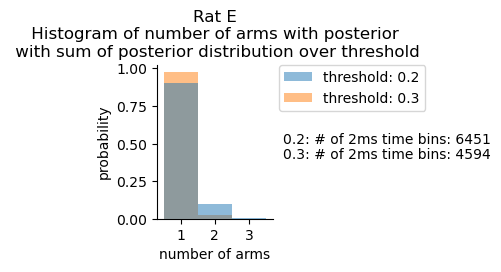

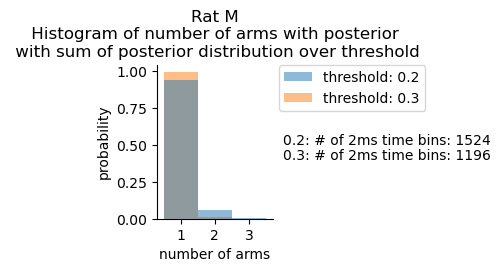

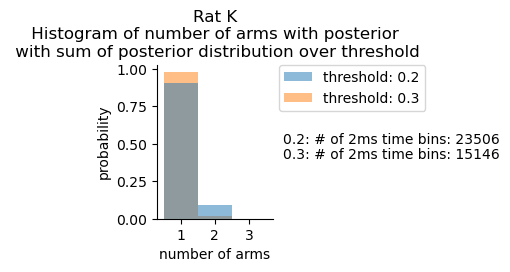

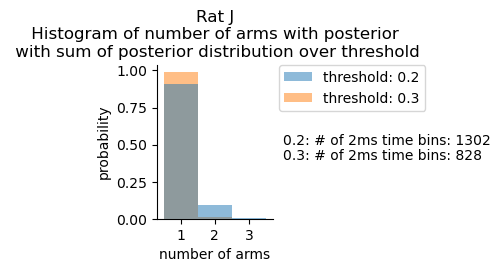

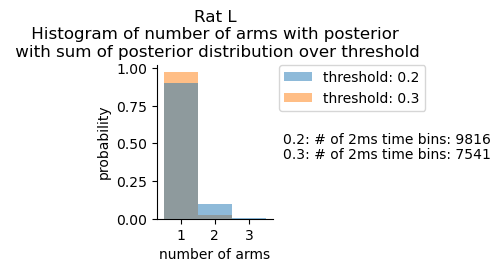

In [20]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure_supp_decode'
figure_outputfolder = '/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/supp_decode/'

for animal in ["eliot","molly","klein","julio","lewis"]:
    data_filename = f"time_bin_arm_concentration_{animal}.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
    with open(output_path, 'rb') as file:
        data = pickle.load(file)
    print(f"Data loaded from {output_path}")
    
    nonlocal_concentration_day = data["nonlocal_concentration"]

    # plotting
    fig, axes = plt.subplots(1, 1, figsize=(1.5, 2),sharey = True)

    plot_ind = 0
    for threshold_nonlocal in [0.2, 0.3]:
        plot_data = nonlocal_concentration_day[threshold_nonlocal]
        plot_data = plot_data[plot_data > 0]
        axes.hist(plot_data,
                  weights = np.ones_like(plot_data)/len(plot_data),
                  bins = [0,1,2,3,4],
                  alpha = 0.5,
                  label = f"threshold: {threshold_nonlocal}",
                  zorder = 100-plot_ind,
                 )
        axes.text(4.5,0.5-0.1*(plot_ind),f"{threshold_nonlocal}: # of 2ms time bins: {len(plot_data)}") #something about the amount of data going in
        plot_ind+=1

    axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    axes.set_xticks(np.array([1,2,3]) + 0.5)
    axes.set_xticklabels(np.array([1,2,3]))
    axes.set_xlim([0.8,4.2])
    axes.set_xlabel("number of arms")
    axes.set_ylabel("probability")
    axes.set_title(f"Rat {animal[0].upper()}\n Histogram of number of arms with posterior \n with sum of posterior distribution over threshold")
    
    axes.spines[['right', 'top']].set_visible(False)
    
    plt.savefig(os.path.join(figure_outputfolder,
        f'decode_concentration_{animal}.pdf'),dpi=300,bbox_inches='tight')

## End here

[2026-03-24 15:05:09,191][WARNING]: Skipped checksum for file with hash: ba372a83-ee79-7175-fc12-a1960dbe7cc2, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_4S4H8PTU0S.nwb
24-Mar-26 15:05:09 Skipped checksum for file with hash: ba372a83-ee79-7175-fc12-a1960dbe7cc2, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_4S4H8PTU0S.nwb


Processing julio 20230808 session: 02_Seq2Session1


[2026-03-24 15:05:20,352][WARNING]: Skipped checksum for file with hash: 53d2daae-456f-f5d5-303a-234fd7d91bb0, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_2U780Y4J53.nwb
24-Mar-26 15:05:20 Skipped checksum for file with hash: 53d2daae-456f-f5d5-303a-234fd7d91bb0, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_2U780Y4J53.nwb


Processing julio 20230808 session: 04_Seq2Session2
No triggered decode found for  {'nwb_file_name': 'julio20230808_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
Processing julio 20230808 session: 06_Seq2Session3


[2026-03-24 15:05:36,560][WARNING]: Skipped checksum for file with hash: 7aa0be73-8de7-4a4c-87e5-0d64106c82db, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_EYBNFNEKMO.nwb
24-Mar-26 15:05:36 Skipped checksum for file with hash: 7aa0be73-8de7-4a4c-87e5-0d64106c82db, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_EYBNFNEKMO.nwb


Processing julio 20230808 session: 08_Seq2Session4


[2026-03-24 15:05:52,044][WARNING]: Skipped checksum for file with hash: 9d17bd28-24a2-5c8e-73c3-05ec292acae8, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_EMUD81587X.nwb
24-Mar-26 15:05:52 Skipped checksum for file with hash: 9d17bd28-24a2-5c8e-73c3-05ec292acae8, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_EMUD81587X.nwb


Processing eliot 20221021 session: 02_Seq2Session1



KeyboardInterrupt



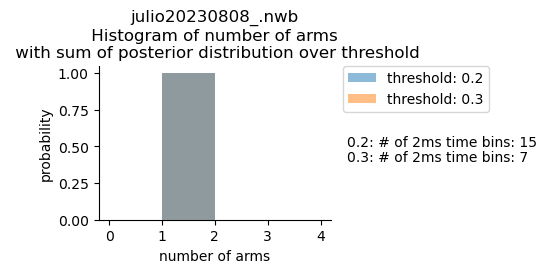

In [18]:

    
    axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    axes.set_xticks(np.array([1,2,3]) + 0.5)
    axes.set_xticklabels(np.array([1,2,3]))
    axes.set_xlim([0.8,4.2])
    axes.set_xlabel("number of arms")
    axes.set_ylabel("probability")
    axes.set_title(f"{nwb_copy_file_name}\n Histogram of number of arms \n with sum of posterior distribution over threshold")

    axes.spines[['right', 'top']].set_visible(False)
    
    plt.savefig(os.path.join(file_path,
        f'decode_concentration_{nwb_copy_file_name}.pdf'),dpi=300,bbox_inches='tight')

In [15]:
%debug

> /home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/changeOfMind_figures/supp_decode_concentration.py(87)return_concentration_day()
     85                                         "interval_list_name":session_name}).fetch1("position_2d"))
     86 
---> 87         triggered_positions = loaded_data["triggered_positions_baseoff"]
     88 
     89         for triggered_position in triggered_positions:



ipdb>  loaded_data


{}


ipdb>  exit


In [93]:
posterior_position_subset = decode_subset.causal_posterior.sum(dim='state')

In [124]:
posterior_by_arm = position_posterior2arm_posterior(posterior_position_subset,linear_map)
arm_id = np.array(pos1d_subset.track_segment_id - 5).astype("int")
posterior_local = np.array([posterior_by_arm[arm_id[t_ind], t_ind] for t_ind in range(len(arm_id))])


In [139]:
threshold = 0.5
time_ind = np.argwhere(posterior_local <= threshold).ravel()

In [151]:
thresholds_nonlocal = [0.1, 0.2, 0.3]

posteriors_nonlocal = {}
for threshold_nonlocal in thresholds_nonlocal:
    posteriors_nonlocal[threshold_nonlocal] = np.array(
        [np.sum(posterior_by_arm[:,t_ind][np.setdiff1d([0,1,2,3,4],arm_id[t_ind])] >= threshold_nonlocal) for t_ind in time_ind]
    )

Text(0.5, 1.0, 'Histogram of number of arms \n with sum of posterior distribution over threshold')

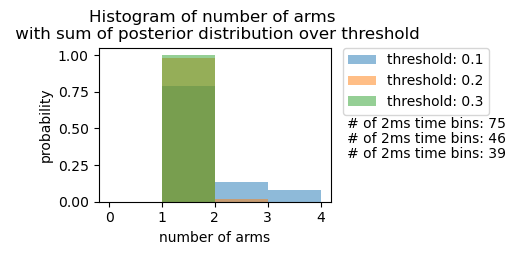

In [162]:
fig, axes = plt.subplots(1, 1, figsize=(3, 2),sharey = True)

plot_ind = 0
for threshold_nonlocal in posteriors_nonlocal.keys():
    plot_data = posteriors_nonlocal[threshold_nonlocal]
    plot_data = plot_data[plot_data > 0]
    axes.hist(plot_data,
              weights = np.ones_like(plot_data)/len(plot_data),
              bins = [0,1,2,3,4],
              alpha = 0.5,
              label = f"threshold: {threshold_nonlocal}"
             )
    axes.text(4.5,0.5-0.1*(plot_ind),f"# of 2ms time bins: {len(plot_data)}") #something about the amount of data going in
    plot_ind+=1

axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
axes.set_xlabel("number of arms")
axes.set_ylabel("probability")
axes.set_title("Histogram of number of arms \n with sum of posterior distribution over threshold")

(array([  26.,   44.,   41.,   30.,   34.,   33.,   56.,   71.,  225.,
        1545.]),
 array([0.00763639, 0.10687277, 0.20610914, 0.30534551, 0.40458187,
        0.50381827, 0.60305464, 0.70229101, 0.80152738, 0.90076375,
        1.00000012]),
 <BarContainer object of 10 artists>)

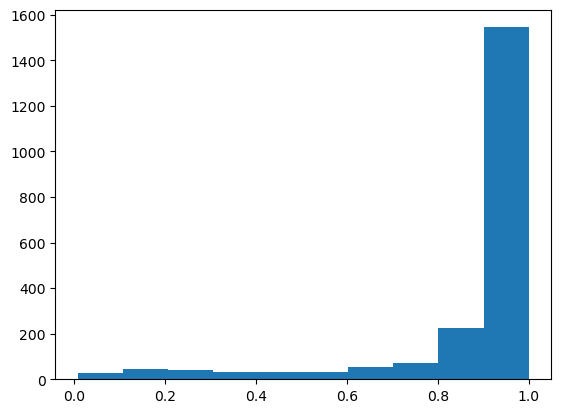

In [121]:
plt.hist(posterior_local)

3.0

In [89]:
pos1d_subset.track_segment_id

,time,linear_position,track_segment_id,projected_x_position,projected_y_position
112577,1.704837e+09,666.296618,9.0,241.465658,144.255267
112578,1.704837e+09,666.383116,9.0,241.543475,144.217499
112579,1.704837e+09,666.469613,9.0,241.621291,144.179732
112580,1.704837e+09,666.556110,9.0,241.699108,144.141964
112581,1.704837e+09,666.642608,9.0,241.776924,144.104196
...,...,...,...,...,...
115489,1.704837e+09,413.277053,7.0,187.394873,59.317346
115490,1.704837e+09,413.340775,7.0,187.377151,59.256139
115491,1.704837e+09,413.404496,7.0,187.359428,59.194932
115492,1.704837e+09,413.468217,7.0,187.341705,59.133725


In [90]:
pos2d_subset

,time,head_position_x,head_position_y,head_orientation,head_velocity_x,head_velocity_y,head_speed
112577,1.704837e+09,240.554924,142.378788,-0.171753,41.023714,-18.811027,45.130919
112578,1.704837e+09,240.636364,142.348485,-0.170437,41.003073,-18.815165,45.113883
112579,1.704837e+09,240.717803,142.318182,-0.169119,40.980772,-18.819121,45.095266
112580,1.704837e+09,240.799242,142.287879,-0.167798,40.956876,-18.822904,45.075131
112581,1.704837e+09,240.880682,142.257576,-0.166474,40.931450,-18.826524,45.053541
...,...,...,...,...,...,...,...
115489,1.704837e+09,189.714015,58.645833,-1.746752,-10.237362,-28.744696,30.513294
115490,1.704837e+09,189.700758,58.583333,-1.744697,-10.221937,-28.642136,30.411510
115491,1.704837e+09,189.687500,58.520833,-1.742638,-10.205830,-28.537695,30.307738
115492,1.704837e+09,189.674242,58.458333,-1.740574,-10.189019,-28.431368,30.201966


In [29]:


    

decode_subset = decode.isel(time = pos2d_subset.index)


# From decode:
# find posterior in local arm sum less than 50%
# 
# For each bin, get # of arms with >10% posterior
# For each bin, get # of arms with >20% posterior
# For each bin, get # of arms with >30% posterior
